INFO: Initializing ResNet50UNet | in_channels=3, out_channels=3, pretrained=True, checkpoint=../weights/UNET_run_x10_01_last_model.pth, se_block=True
INFO: Loading ResNet50 weights from checkpoint: ../weights/UNET_run_x10_01_last_model.pth


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO: ResNet50UNet Parameter Summary (Top-Level Modules):
INFO: --------------------------------------------------------------------------------
INFO: in_conv                   | Total: 9536                 | Trainable: 9,536
INFO: maxpool                   | Total: 0                    | Trainable: 0
INFO: enc1                      | Total: 215808               | Trainable: 215,808
INFO: enc2                      | Total: 1219584              | Trainable: 1,219,584
INFO: enc3                      | Total: 7098368              | Trainable: 7,098,368
INFO: enc4                      | Total: 14964736             | Trainable: 14,964,736
INFO: up4                       | Total: 16551456             | Trainable: 16,551,456
INFO: up3                       | Total: 2959120              | Trainable: 2,959,120
INFO: up2                       | Total: 740232               | Trainable: 740,232
INFO: up1                       | Total: 148420               | Trainable: 148,420
INFO: up0            

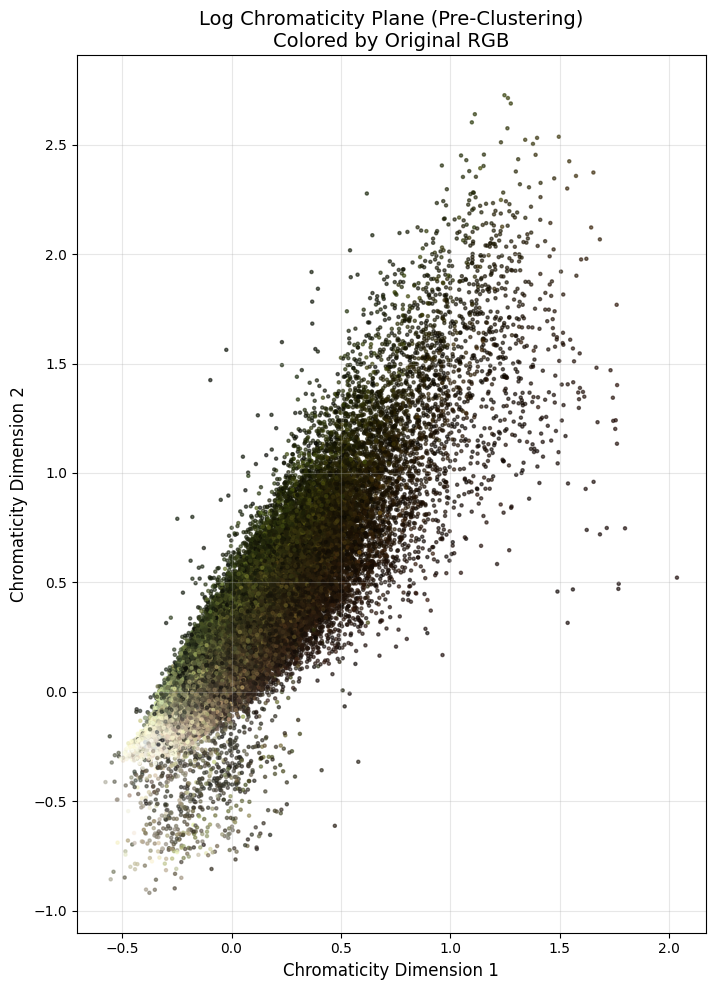

INFO: K-Means clustering: 3 clusters


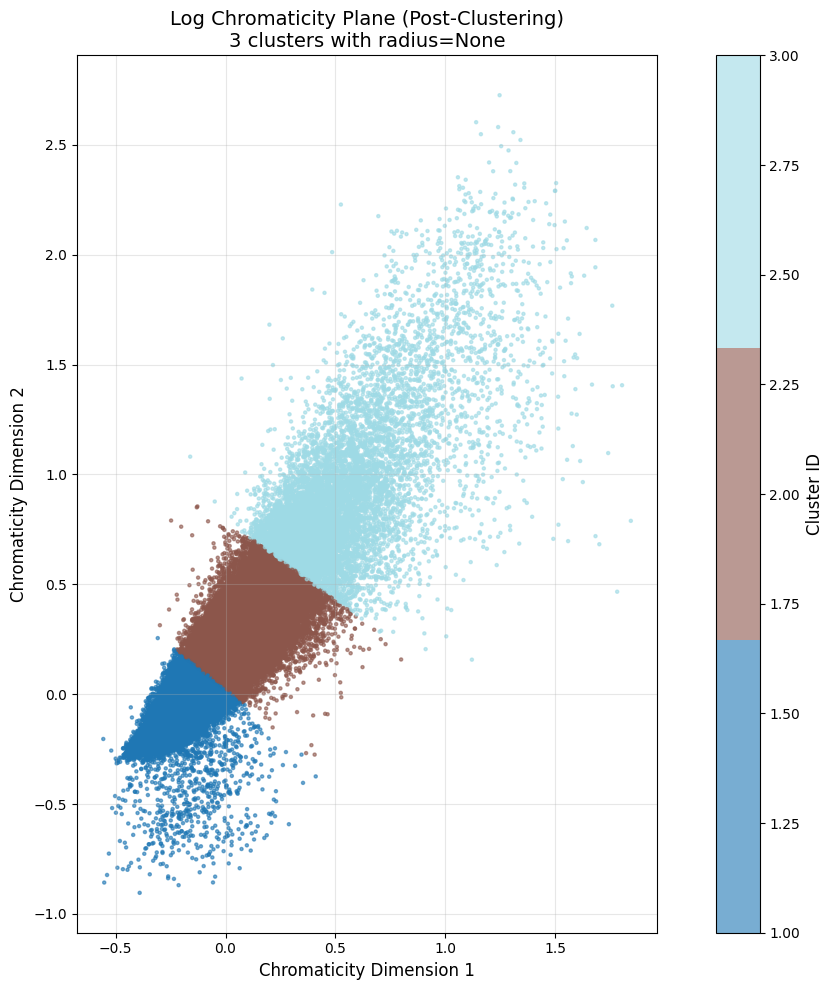

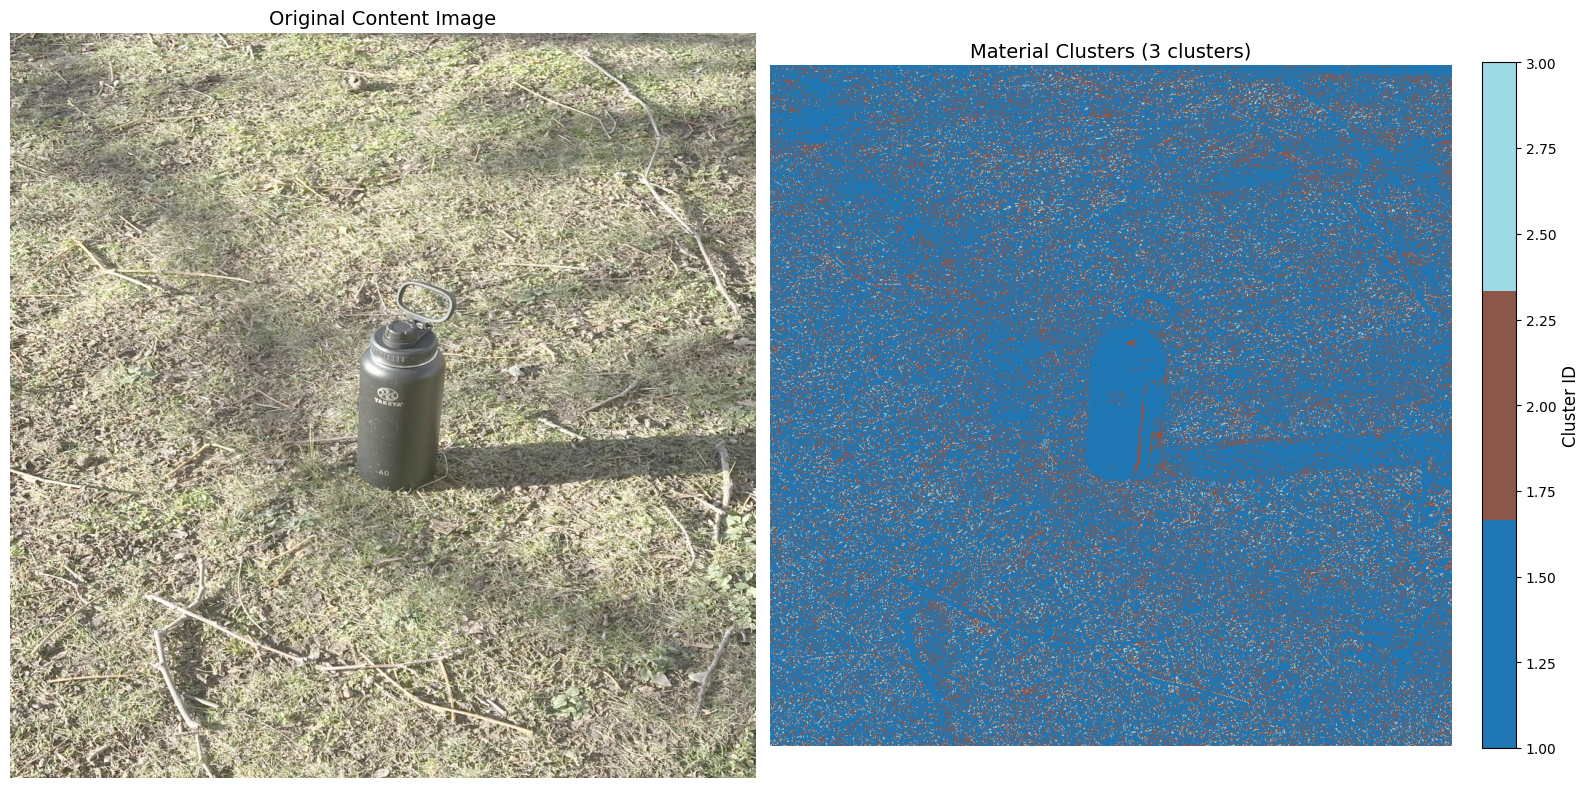

INFO: Estimated illumination vector norm 3.0296941174491465


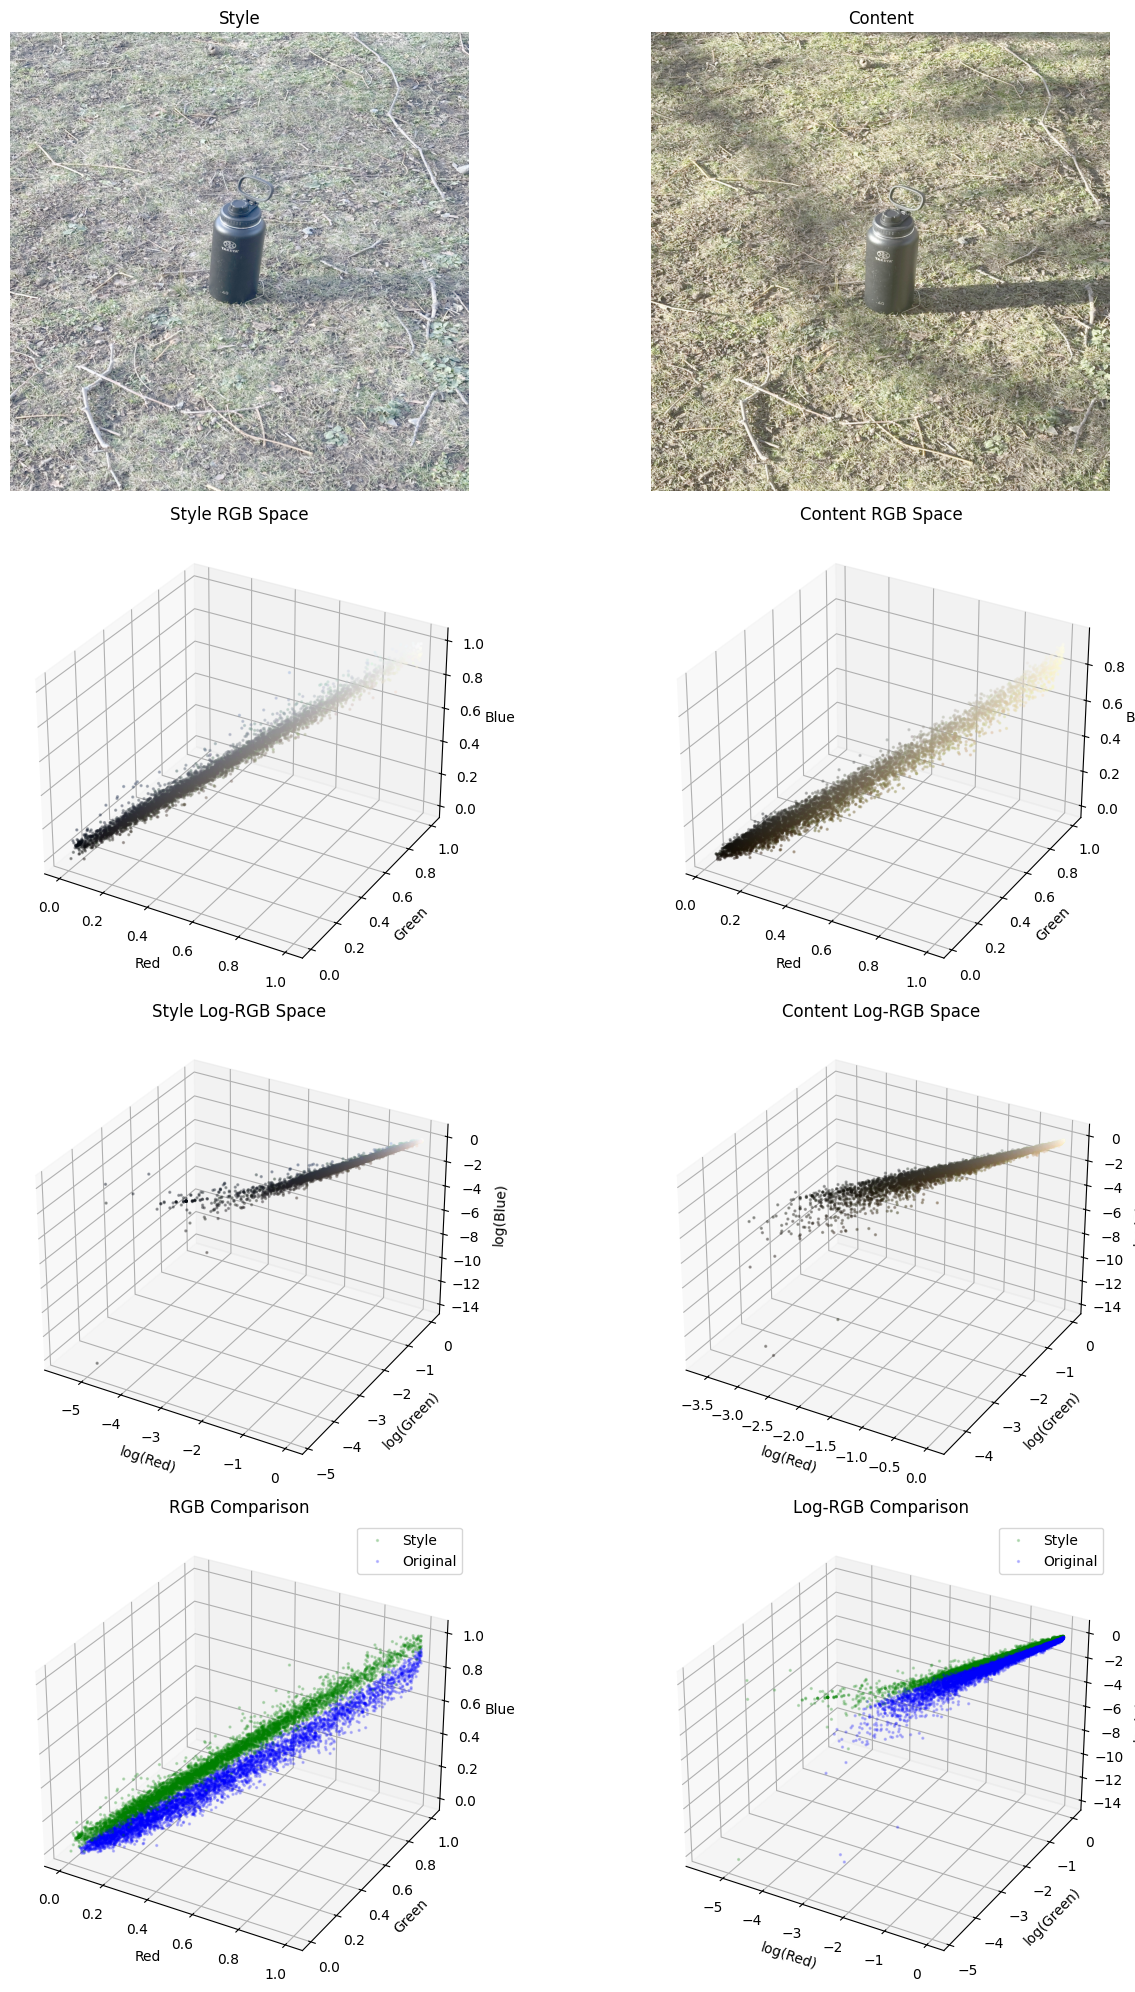

max linear chroma 255
log_chroma_content.max()=np.float64(12.791636795405097)
log_chroma_content.shape=(1024, 1024, 3)
content_sampled.shape=(10000, 3)


ValueError: RGBA values should be within 0-1 range

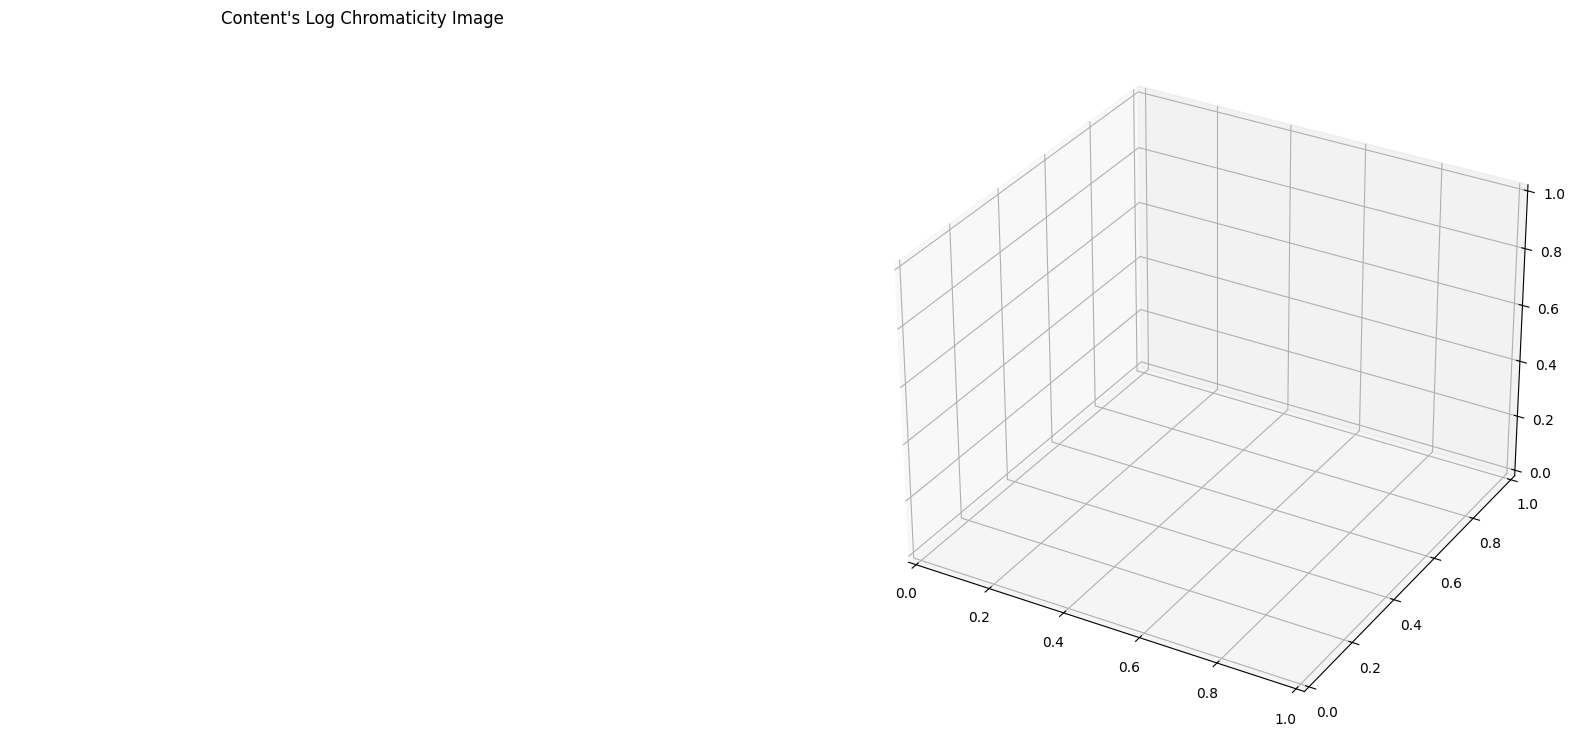

In [9]:
from bidr_relight.main import relight_content_image
from bidr_relight.plot import plot_bin_masks, plot_rgb_space_ax
from bidr_relight.bidr_process import project_to_log_chromaticity_plane
import numpy as np
import torch

from skimage.io import imread, imsave
import matplotlib.pyplot as plt
import os

%load_ext autoreload
%autoreload 2

log_chroma_content, log_imgs, isd_maps = relight_content_image(
    content_path="../data/compressed/bottle_sun.tiff",
    style_path="../data/compressed/bottle_cloudy.tiff",
    #content_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000212.tiff",
    #style_path="../data/RAWAE/raw_maxwell_2023_05_26_ - 000225.tiff",
    isd_model="unet",  # mock, vit, unet
    isd_model_path="../weights/UNET_run_x10_01_last_model.pth",
    output_path="../data/target.png",
    shading_only=True,
    compression_factor=0.5,
    clustering_method="kmeans", # greedy, kmeans
    n_clusters=3,
    bin_radius=0.5
)

# Result is obviously still wrong:
# - the ISD map result doesn't look right (if you just print it out), and each time you run this function, there seems to be some randomness whenever we redefine model and reload (does it even load properly),
# the ISD map shows WAY TOO different results every time.

In [23]:
isd_maps[0]

array([[[-0.96262574,  0.02352835,  0.26981157],
        [-0.9612    ,  0.01847846,  0.27523297],
        [-0.9609648 ,  0.02097406,  0.27587426],
        ...,
        [-0.96071523,  0.02175428,  0.27668187],
        [-0.96061486,  0.02091638,  0.27709502],
        [-0.96066254,  0.01690118,  0.27720344]],

       [[-0.96281695,  0.01850644,  0.26951998],
        [-0.9631611 ,  0.00877119,  0.26878217],
        [-0.96282196,  0.01183122,  0.26987755],
        ...,
        [-0.96264625,  0.01281013,  0.27045882],
        [-0.96252596,  0.01062285,  0.27098128],
        [-0.96186596,  0.01144644,  0.2732816 ]],

       [[-0.96363825,  0.01617621,  0.26672018],
        [-0.9641085 ,  0.00716217,  0.2654116 ],
        [-0.9634094 ,  0.0111149 ,  0.26780328],
        ...,
        [-0.9633812 ,  0.01310033,  0.26781553],
        [-0.9630911 ,  0.01115306,  0.2689447 ],
        [-0.96225023,  0.01147973,  0.27192408]],

       ...,

       [[-0.9636537 ,  0.01623764,  0.26666054],
        [-0

Testing whether log chroma projection work (verified)

In [24]:
syn_isd_map = np.zeros_like(log_imgs[0])
syn_isd_map[..., 0] = 1.0
projected = project_to_log_chromaticity_plane(
    log_imgs[0], isd_map=syn_isd_map, plane_offset=np.zeros(3)
)

/home/richard/workspaces/CV/bidr_relight/bidr_relight/plot.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


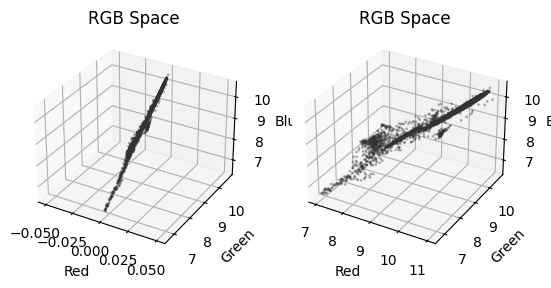

In [18]:
plt.figure()
ax = plt.subplot(1, 2, 1, projection="3d")
ax2 = plt.subplot(1, 2, 2, projection="3d")


# Sample pixels for log-RGB plotting
num_samples = 5000
projected_flat = projected.reshape(-1, 3)
logi_flat = log_imgs[0].reshape(-1, 3)
if len(projected_flat) > num_samples:
    indices = np.random.choice(len(projected_flat), num_samples, replace=False)
    projected_flat = projected_flat[indices]
    logi_flat = logi_flat[indices]

plot_rgb_space_ax(
    projected_flat,
    (0.2, 0.2, 0.2),
    ax,
)

logi = log_imgs[0].reshape(-1, 3)
plot_rgb_space_ax(
    logi_flat,
    (0.2, 0.2, 0.2),
    ax2,
)